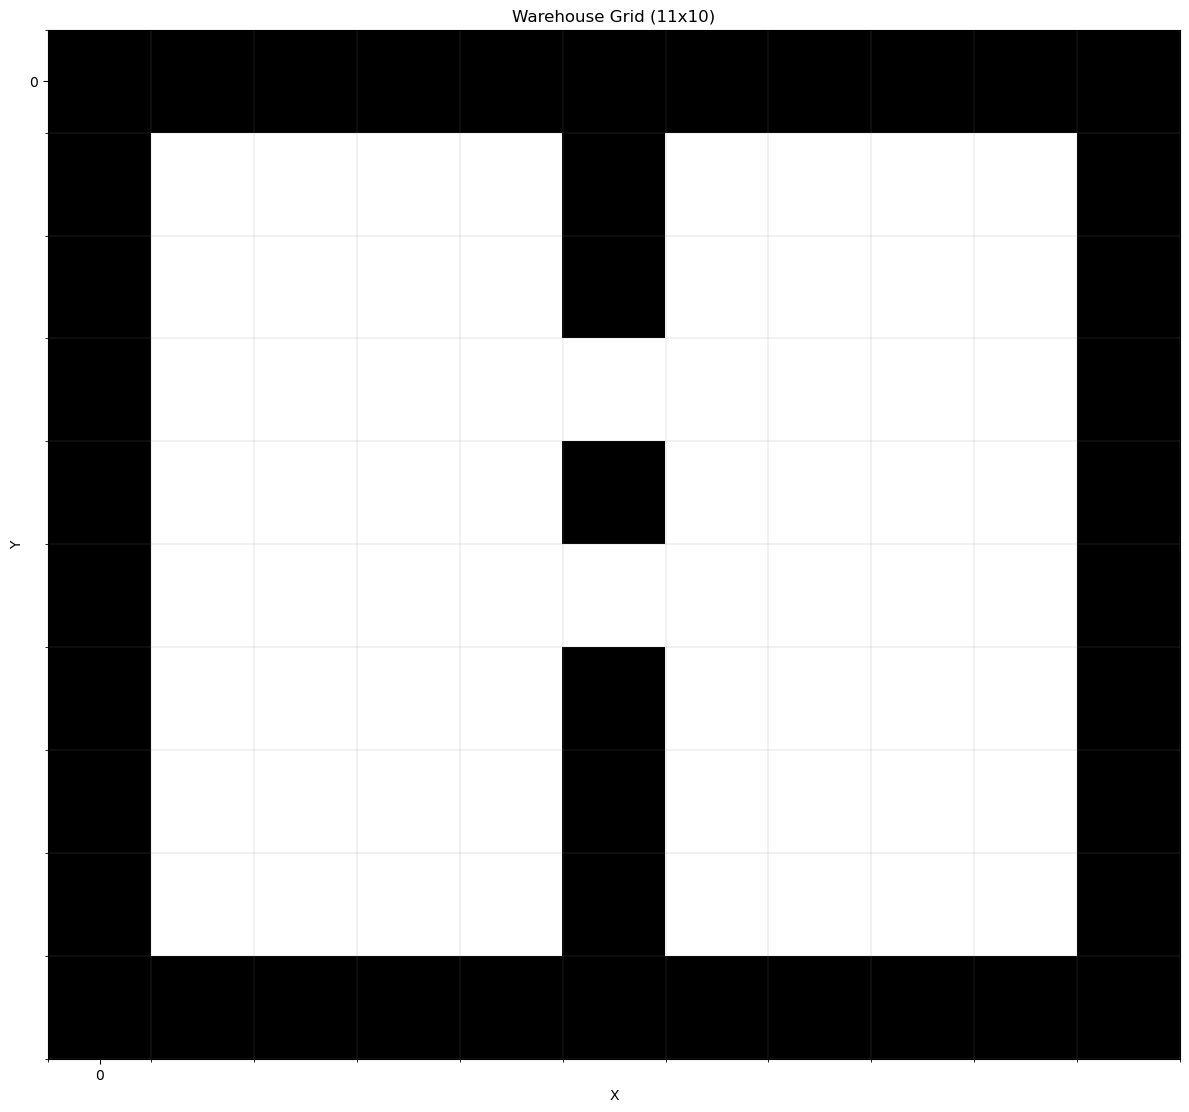

In [1]:
class GridEnvironment:
    """ Represents the grid map"""

    def __init__(self, filename):
        """ Load grid from file """
        self.grid = self.load_from_file(filename)

        """ Initialize grid with dimensions """
        self.height = len(self.grid)
        self.width = len(self.grid[0]) if self.height > 0 else 0

    def is_valid_position(self, x, y):
        """ Check if position is within grid bounds """
        return 0 <= x < self.width and 0 <= y < self.height

    def is_walkable(self, x, y):
        """ Check if position is walkable (not obstacle)"""
        return self.is_valid_position(x, y) and self.grid[y][x]

    def get_neighbors(self, x, y):
        """Get adjacent cells (4-directional)"""
        directions = [(0,1), (1,0), (0,-1), (-1,0)]
        neighbors = []

        for dx, dy in directions:
            nx, ny = x + dx, y + dy
            if self.is_walkable(nx, ny):
                neighbors.append((nx, ny))

        return neighbors

    def load_from_file(self, filename):
        """ Load grid from file """
        grid = []
        with open(filename, 'r') as f:
            for line in f:
                row = []
                for char in line.strip():
                    if char == '.':
                        row.append(True)
                    elif char == 'T':
                        row.append(False)
                grid.append(row)
        return grid

    def save_to_file(self, filename):
        """ Save grid to file """
        with open(filename, 'w') as f:
            for row in self.grid:
                line = ''.join(['.' if cell else 'T' for cell in row])
                f.write(line + '\n')

    def visualize(self):
        import matplotlib.pyplot as plt
        from matplotlib.colors import ListedColormap
        import numpy as np
        """Visualize the warehouse grid"""
        grid_array = np.array(self.grid, dtype=int)
        
        fig, ax = plt.subplots(figsize=(12, 12))
        
        cmap = ListedColormap(['black', 'white'])
        ax.imshow(grid_array, cmap=cmap, origin='upper', interpolation='nearest')
        
        ax.set_xticks(np.arange(-0.5, self.width, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, self.height, 1), minor=True)
        
        ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.3, alpha=0.5)
        
        ax.set_xticks(np.arange(0, self.width, 20))
        ax.set_yticks(np.arange(0, self.height, 20))
        

        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_title(f"Warehouse Grid ({self.width}x{self.height})")
        
        plt.tight_layout()
        plt.show()

very_small_grid = GridEnvironment('./../maps/very-small.txt')
very_small_grid.visualize()

# medium_grid = GridEnvironment('./maps/medium.txt')
# medium_grid.visualize()

# large_grid = GridEnvironment('./maps/large.txt')
# large_grid.visualize()

# very_large_grid = GridEnvironment('./maps/very-large.txt')
# very_large_grid.visualize()



In [2]:
class Robot:
    """Represents a single robot in the warehouse"""
    def __init__(self, robot_id, grid, start_pos, goal_pos, color='blue'):
        """Initialize robot with grid reference
        
        Args:
            robot_id (int): Unique identifier for robot
            grid (GridEnvironment): The grid this robot moves in
            start_pos (tuple): Starting (x, y) position
            goal_pos (tuple): Goal (x, y) position
            color (str): Robot color for visualization
        """
        self.robot_id = robot_id
        self.grid = grid
        self.current_pos = start_pos
        self.goal_pos = goal_pos
        self.path = []  # Planned path: list of (x, y) coordinates
        self.path_index = 0  # Current position in path
        self.color = color
    
    def get_current_position(self):
        """Get current position
        
        Returns:
            tuple: Current (x, y) position
        """
        return self.current_pos

    def get_goal_position(self):
        """Get goal position
        
        Returns:
            tuple: Goal (x, y) position
        """
        return self.goal_pos

    def move_to(self, position):
        """Move robot to new position
        
        Args:
            position (tuple): New (x, y) position
        """
        if self.grid.is_walkable(position[0], position[1]):
            self.current_pos = position
        else:
            raise ValueError(f'Cannot move to non-walkable position {position}')

    def is_at_goal(self):
        """Check if robot reached goal
        
        Returns:
            bool: True if at goal position
        """
        return self.current_pos == self.goal_pos

    def get_neighbors_from_grid(self):
        """Get valid neighboring positions using grid method
        
        Returns:
            List[tuple]: List of valid neighbor (x, y) coordinates
        """
        x, y = self.current_pos
        return self.grid.get_neighbors(x, y)

    def get_path(self):
        """Get stored path
        
        Returns:
            List[tuple]: Planned path as list of (x, y) coordinates
        """
        return self.path

    def set_path(self, path):
        """Store path for robot
        
        Args:
            path (List[tuple]): Path as list of (x, y) coordinates
        """
        self.path = path
        self.path_index = 0

    def get_position_at_time(self, time_step):
        """Get robot's position at a specific time step (for collision detection)
        
        Args:
            time_step (int): Time step
            
        Returns:
            tuple: (x, y) position at that time, or goal if past path length
        """
        if time_step < len(self.path):
            return self.path[time_step]
        else:
            # Robot waits at goal after reaching it
            return self.path[-1] if self.path else self.current_pos



In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from collections import defaultdict
from IPython.display import HTML


all_paths = [

    [(1,1),(2,1),(3,1),(4,1),(4,2),(4,3),(3,3),(2,3),(1,3),(1,2),(1,1)],

    [(9,1),(8,1),(7,1),(6,1),(6,2),(6,3),(7,3),(8,3),(9,3),(9,2),(9,1)],

    [(1,8),(2,8),(3,8),(4,8),(4,7),(4,6),(4,5),(3,5),(2,5),(1,5),(1,6),(1,7),(1,8)],

    [(9,5),(8,5),(7,5),(6,5),(6,6),(6,7),(6,8),(7,8),(8,8),(9,8),(9,7),(9,6),(9,5)],

]

# Create robots
robots = []
colors = ['blue', 'red', 'green', 'purple']

for i, path in enumerate(all_paths):
    robot = Robot(
        robot_id=i,
        grid=very_small_grid,
        start_pos=path[0],
        goal_pos=path[-1],
        color=colors[i]
    )
    robot.set_path(path)
    robots.append(robot)


RuntimeError: x must be a sequence

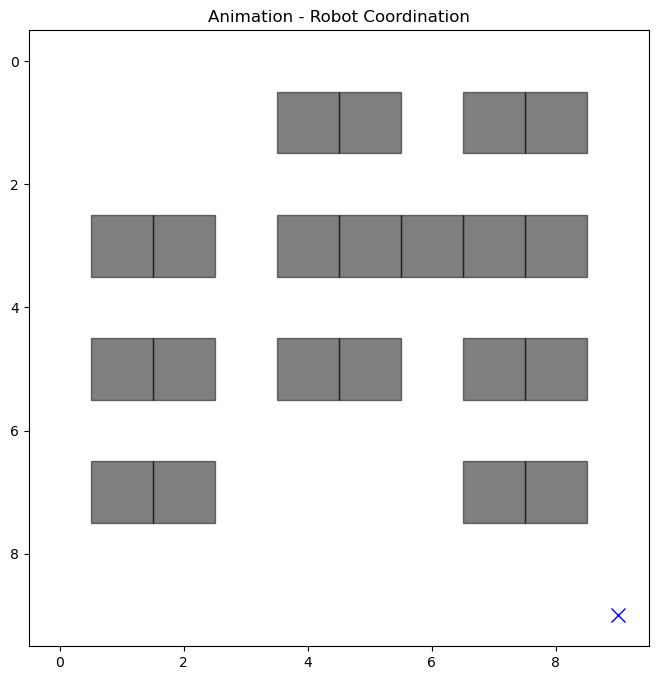

In [ ]:
# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_title("Robot Coordination Animation", fontsize=14, fontweight='bold')
ax.set_xlim(-0.5, very_small_grid.width - 0.5)
ax.set_ylim(-0.5, very_small_grid.height - 0.5)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.grid(True, alpha=0.3)
ax.invert_yaxis()  

# Draw obstacles
for y in range(very_small_grid.height):
    for x in range(very_small_grid.width):
        if not very_small_grid.is_walkable(x, y):
            ax.add_patch(plt.Rectangle((x - 0.5, y - 0.5), 1, 1, color='black', alpha=0.5))

# Mark goal positions with X markers
robot_colors = plt.cm.tab10(np.linspace(0, 1, len(robots)))
for i, robot in enumerate(robots):
    goal_x, goal_y = robot.get_goal_position()
    ax.plot(goal_x, goal_y, 'x', color=robot_colors[i], markersize=12, markeredgewidth=2)

# Create line objects for paths and scatter points for robots
path_lines = []
robot_dots = []

for i, robot in enumerate(robots):
    # Draw full path as a line
    path = robot.get_path()
    path_x = [p[0] for p in path]
    path_y = [p[1] for p in path]
    line, = ax.plot(path_x, path_y, '-', color=robot_colors[i], alpha=0.3, linewidth=1)
    path_lines.append(line)
    
    # Draw robot as a dot
    dot, = ax.plot([], [], 'o', color=robot_colors[i], markersize=10, 
                    label=f'Robot {i}', zorder=5)
    robot_dots.append(dot)

# Add legend
ax.legend(loc='upper left', fontsize=10)

# Get the maximum path length
max_path_length = max(len(robot.get_path()) for robot in robots)

# Update function for animation
def update(frame):
    """Update robot positions for each frame"""
    for i, robot in enumerate(robots):
        # Get position at current time step
        pos = robot.get_position_at_time(frame)
        robot_dots[i].set_data([pos[0]], [pos[1]])
    
    return robot_dots

# Create animation
ani = FuncAnimation(
    fig,
    update,
    frames=max_path_length,
    interval=200,  # 200ms per frame
    blit=True,
    repeat=True
)

plt.tight_layout()
HTML(ani.to_jshtml())